# Sentiment Analysis Using VADER

## Importing Libraries and Initial Data Loading

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

#Download VADER lexicon 
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/hendriksippel/nltk_data...


True

In [2]:
#Define path to the dataset and load it
data_path = '../data/spotify_reviews.csv'
data = pd.read_csv(data_path)

## Preprocessing

In [3]:
# Function to clean text
def clean_text(text):
    if pd.isnull(text):
        return ""
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    return text

data['cleaned_content'] = data['content'].apply(clean_text)

## Model Implementation 

In [4]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
data['compound'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['compound'])
data['negative'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['neg'])
data['neutral'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['neu'])
data['positive'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['pos'])

# Verify that the scores sum to 1 for individual reviews
data['Sum'] = data['negative'] + data['neutral'] + data['positive']
print(data[['negative', 'neutral', 'positive', 'Sum']].head())

# Extract the year from 'at' column
data['Year'] = pd.to_datetime(data['at']).dt.year

# Ensure that the columns for grouping are numeric
numeric_columns = ['compound', 'positive', 'negative', 'neutral']

# Group by 'Year' and calculate mean sentiment scores
sentiment_by_year = data.groupby('Year')[numeric_columns].mean().reset_index()

# Verify that the proportions sum to 1 when averaged
sentiment_by_year['Sum'] = sentiment_by_year['positive'] + sentiment_by_year['negative'] + sentiment_by_year['neutral']
print(sentiment_by_year)

   negative  neutral  positive    Sum
0     0.000    0.256     0.744  1.000
1     0.095    0.765     0.139  0.999
2     0.000    0.000     1.000  1.000
3     0.000    0.561     0.439  1.000
4     0.000    0.748     0.252  1.000
   Year  compound  positive  negative   neutral       Sum
0  2018  0.381084  0.147842  0.068122  0.784027  0.999991
1  2019  0.234500  0.128474  0.080492  0.791034  1.000000
2  2020  0.275276  0.131035  0.076926  0.792034  0.999995
3  2021  0.180334  0.120283  0.083260  0.796452  0.999996
4  2022  0.200535  0.123020  0.082983  0.794001  1.000004
5  2023  0.122773  0.125073  0.093052  0.781875  0.999999
6  2024  0.152412  0.157426  0.090677  0.751680  0.999783


### Visualizations

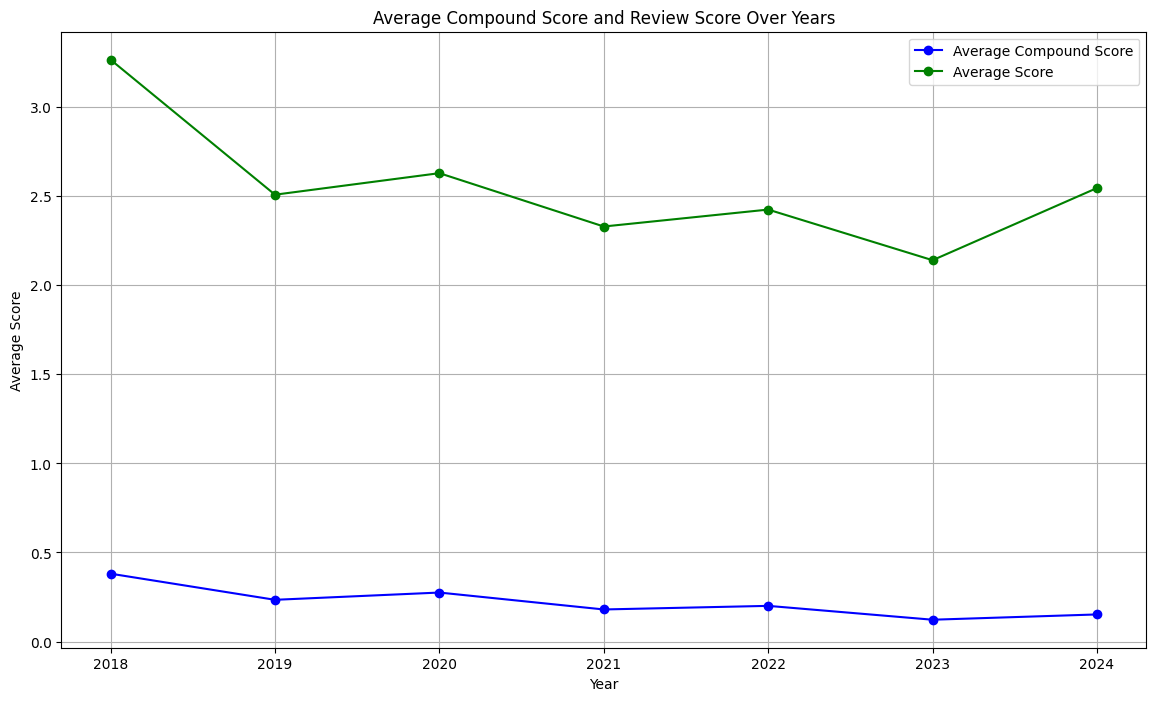

In [5]:
# Plotting the average compound score and average score from the original CSV
plt.figure(figsize=(14, 8))

plt.plot(sentiment_by_year['Year'], sentiment_by_year['compound'], marker='o', label='Average Compound Score', color='blue')
plt.plot(data.groupby('Year')['score'].mean(), marker='o', label='Average Score', color='green')

plt.xlabel('Year')
plt.ylabel('Average Score')
plt.title('Average Compound Score and Review Score Over Years')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

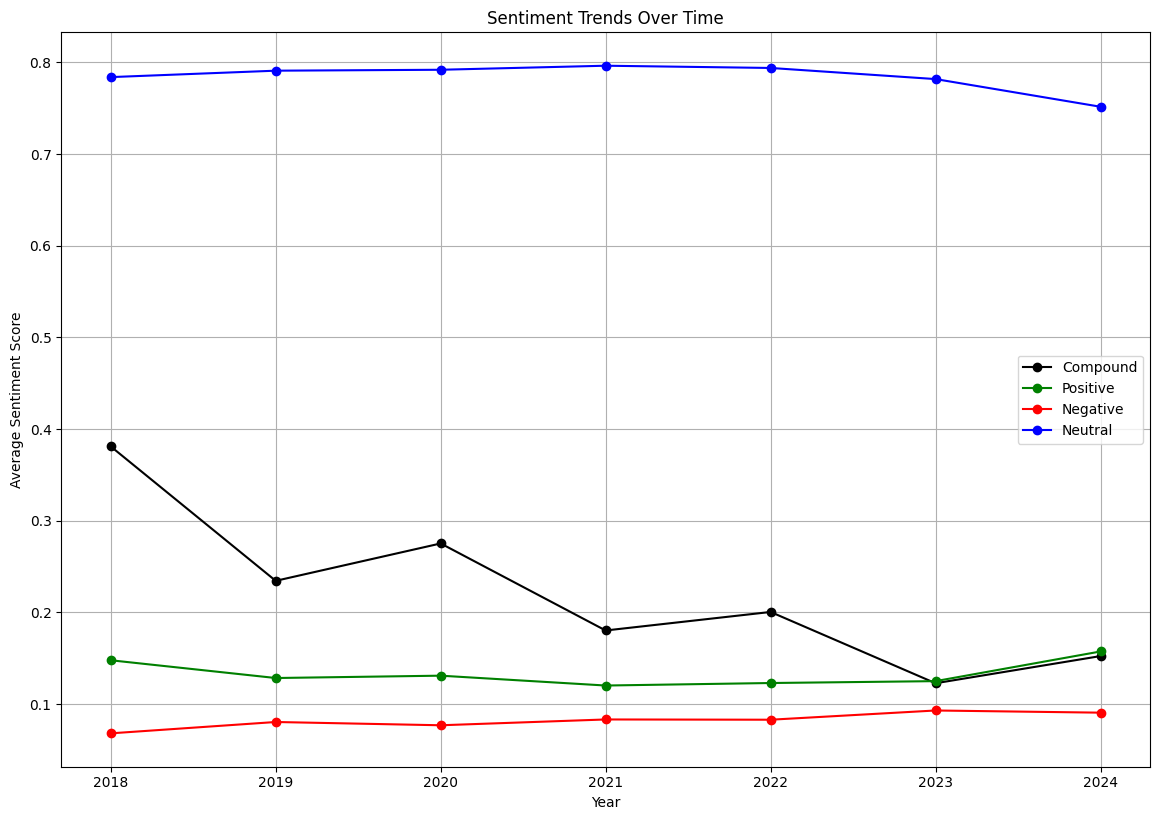

In [6]:
# Plotting the figure
plt.figure(figsize=(11.7, 8.3))  
plt.plot(sentiment_by_year['Year'], sentiment_by_year['compound'], label='Compound', marker='o', color='black')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['positive'], label='Positive', marker='o', color='green')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['negative'], label='Negative', marker='o', color='red')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['neutral'], label='Neutral', marker='o', color='blue')

plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Trends Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()